# Titanic Dataset — Exploratory Data Analysis

## 1. Setup & Imports


In [52]:
import pandas as pd

## 2. Loading the Dataset

In [53]:
df = pd.read_csv("train.csv")

## 3. First Look at the Data

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Dataset Overview (Shape & Info)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [56]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 5. Missing Values

In [57]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 6. Column Types (Categorical vs Numerical)

| Categorical | Numerical |
|---|---|
| Sex | Age |
| Embarked | SibSp |
| Cabin | Parch |
| Name | Fare |
| Ticket | PassengerId |
| Pclass *(ordinal)* | |
| Survived *(binary target)* | |

---

## 7. Summary — Key Findings

- **Dataset size:** 891 rows, 12 columns
- **Missing values:** Cabin (687, 77.1%), Age (177, 19.9%), Embarked (2, 0.2%)
- **Key observation:** The Cabin column is missing ~77% of its values, making it unreliable to use as-is. A better approach is engineering a new feature — e.g. `Has_Cabin` (Yes/No) — to still capture partial signal instead of dropping the column entirely.

---

# Task 2 — Data Cleaning & Visualization

This section builds on the Week 1 EDA above. Here I clean the missing values, 
detect outliers, and create visualizations to better understand what drives 
survival in the Titanic dataset.

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully")

Libraries loaded successfully


### 2.1 Handling Missing Values

In [59]:
# Fill Age with median value
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has ~77% missing — instead of filling, create a new feature
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df = df.drop('Cabin', axis=1)

# Verify no missing values remain (except Cabin which we dropped)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

### Why these choices?

- **Age (median fill):** Age has some high outliers (older passengers), so using the median instead of the mean avoids skewing the filled values.
- **Embarked (mode fill):** Only 2 values were missing, so filling with the most common port keeps the impact minimal and avoids losing 2 whole rows.
- **Cabin (dropped, replaced with `Has_Cabin`):** With ~77% missing, filling would introduce mostly guessed data. Instead, a binary flag (`Has_Cabin`) preserves the signal — whether cabin info was recorded — which may correlate with passenger class or survival.

### 2.2 Outlier Detection

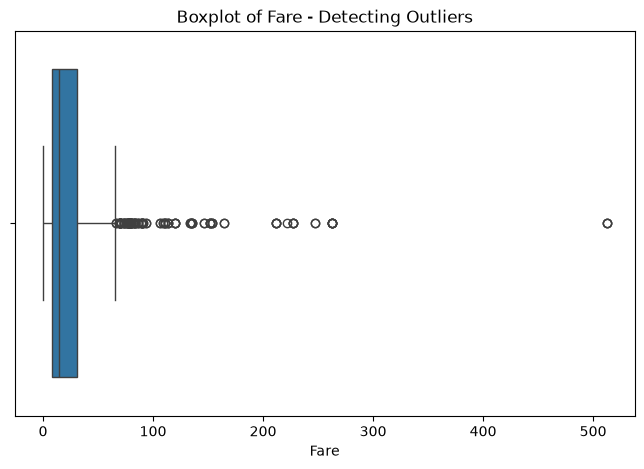

In [60]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Detecting Outliers')
plt.show()

### Outlier Observation

The Fare boxplot shows most passengers paid under 70, but there's a long tail 
of outliers reaching all the way to ~512. These are likely first-class 
passengers or those with premium cabins, and they significantly skew the mean 
fare — which is why median-based analysis is often preferred for this column.

### 2.3 Visualization 1 — Age Distribution (Histogram)

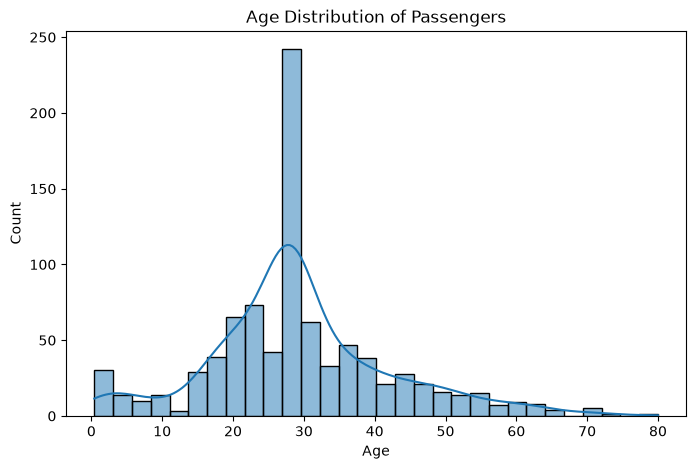

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 2.4 Visualization 2 — Survival by Sex (Bar Chart)

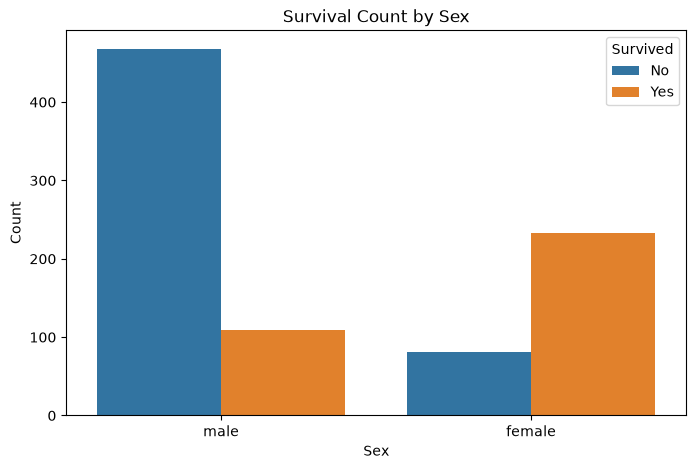

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 2.5 Visualization 3 — Correlation Heatmap

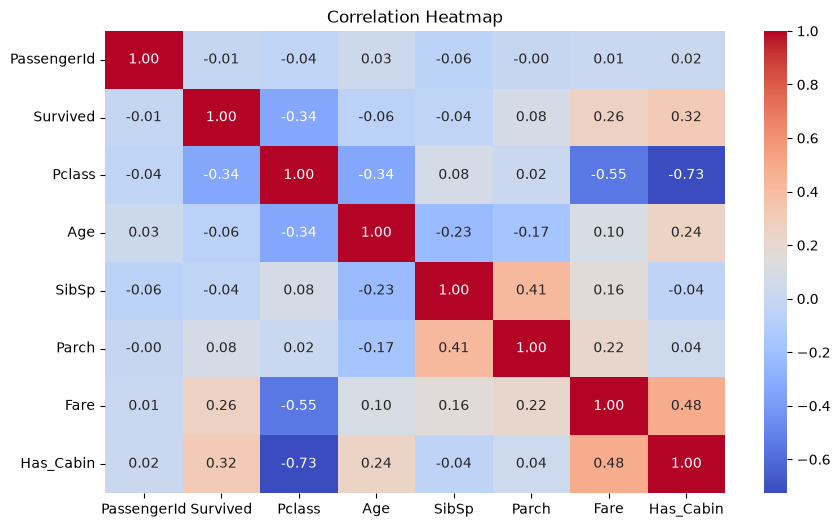

In [63]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 2.6 Which Feature Affects Survival Most?

Based on the correlation heatmap and visualizations, **Pclass (passenger class)** 
appears to have the strongest relationship with survival (correlation: -0.34). 
Passengers in 1st class had noticeably higher survival rates than 3rd class — 
likely due to cabin location (closer to lifeboats) and priority during evacuation.

**Sex** also shows a very strong pattern in the bar chart — far more females 
survived than males, consistent with the "women and children first" 
evacuation policy. Together, Pclass and Sex appear to be the two strongest 
predictors of survival in this dataset.